<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Computational Statistics / Random Number Generation</h1>
<h3 style="margin: 0;  color: #1e1a66">Samoliuk Oleksandr</h3>
</div>

Imports:

In [9]:
import numpy as np
import matplotlib.pyplot as plt

---

### Inversion method:

In [111]:
def inverse_transform_sampling(inv_cdf, n_samples):
    u = np.random.uniform(0, 1, size=n_samples)
    return inv_cdf(u)

def numerical_inverse_transform_sampling(x_grid, pdf_values, n_samples):
    dx = np.diff(x_grid, prepend=x_grid[0])
    cdf = np.cumsum(pdf_values * dx)
    cdf /= cdf[-1]
    
    u = np.random.uniform(0.0, 1.0, size=n_samples)
    return np.interp(u, cdf, x_grid)

In [112]:
lam = 1.5
inv_cdf_exp = lambda u: -np.log(1.0 - u) / lam
samples_exp = inverse_transform_sampling(inv_cdf_exp, n_samples=10000)

In [113]:
x_grid = np.linspace(-5, 5, 1000)
pdf_grid = np.exp(-(x_grid + 2)**2) + 0.5 * np.exp(-(x_grid - 2)**2)
samples_custom = numerical_inverse_transform_sampling(x_grid, pdf_grid, n_samples=10000)

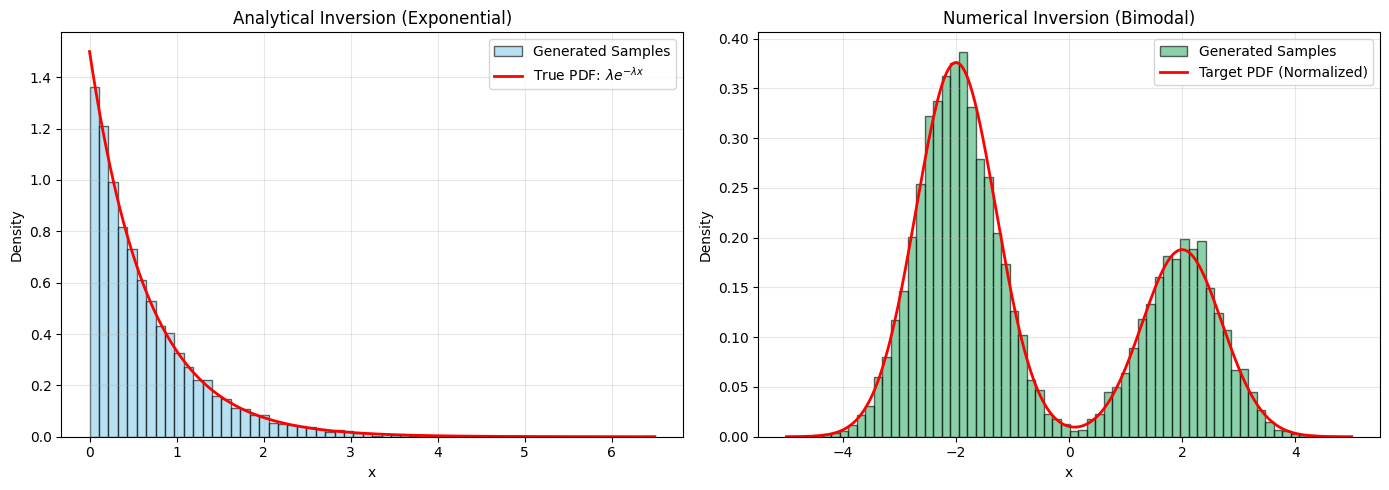

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(samples_exp, bins=60, density=True, 
             alpha=0.6, color='skyblue', edgecolor='black', label='Generated Samples')
x_exp = np.linspace(0, np.max(samples_exp), 500)
pdf_exp_true = lam * np.exp(-lam * x_exp)
axes[0].plot(x_exp, pdf_exp_true, 'r-', lw=2, label=r'True PDF: $\lambda e^{-\lambda x}$')
axes[0].set_title('Analytical Inversion (Exponential)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(samples_custom, bins=60, density=True, 
             alpha=0.6, color='mediumseagreen', edgecolor='black', label='Generated Samples')
pdf_area = np.trapz(pdf_grid, x_grid)
axes[1].plot(x_grid, pdf_grid / pdf_area, 'r-', lw=2, label='Target PDF (Normalized)')
axes[1].set_title('Numerical Inversion (Bimodal)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Outputs/Random_Number_Generation/Inversion_Method.png')
plt.show()

---

### Box–Muller Method:

$$
U_1 \sim Unif(0,1) \qquad U_2 \sim Unif(0,1) \\[15pt]
X_1 = \sqrt{-2\ln(U_1)} \cdot \cos(2\pi U_2) \\[7pt]
X_2 = \sqrt{-2\ln(U_1)} \cdot \sin(2\pi U_2) \\[15pt]

\begin{pmatrix} X_1 \\ X_2 \end{pmatrix} \sim \mathcal{N}\left(\begin{pmatrix} 0 \\ 0 \end{pmatrix}, \mathbf{I}\right)
$$

In [71]:
def Box_Muller(size):
    u = np.random.uniform(low=1e-10, high=1, size=(size, 2))
    u1, u2 = u[:, 0], u[:, 1]

    n1 = np.sqrt(-2 * np.log(u1)) * np.cos(2*np.pi * u2)
    n2 = np.sqrt(-2 * np.log(u1)) * np.sin(2*np.pi * u2)

    return np.column_stack((n1, n2))

In [102]:
array = Box_Muller(1300)
array

array([[-0.38841894,  0.55908096],
       [-0.4167231 ,  0.86729239],
       [-1.48314252, -0.03226881],
       ...,
       [-0.64333494, -2.21852794],
       [ 1.60880017,  0.86614353],
       [ 1.0154634 , -0.10514039]])

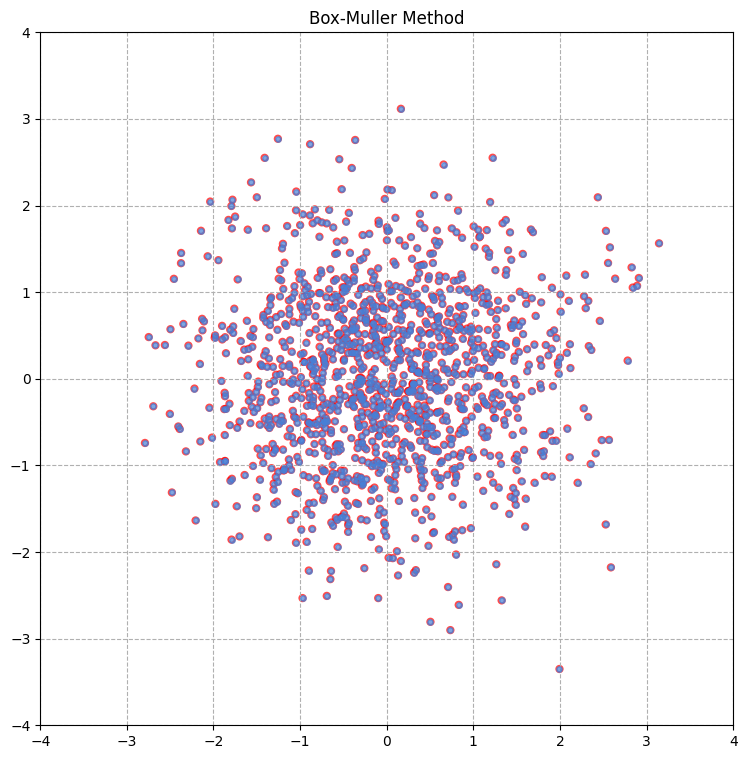

In [110]:
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(array[:, 0], array[:, 1], c="#4780D7", s=15, alpha=0.7, label='LHS Samples $\\Xi$', zorder=3)
ax.scatter(array[:, 0], array[:, 1], s=20, alpha=0.7, linewidths=1.5, facecolors='none', edgecolors='r', zorder=1)

ax.set_xlim([-4, 4])
ax.set_ylim([-4, 4])
ax.grid(True, linestyle='--', zorder=0)
ax.set_aspect('equal')
ax.set_title('Box-Muller Method')
plt.savefig('Outputs/Random_Number_Generation/Box_Muller.png')
plt.show()

---

### Rejection Sampling: